In [3]:
import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pymc as pm
import arviz as az

rng = np.random.RandomState(1234)
az.style.use("arviz-darkgrid")

In [4]:
mu_true = -0.05
sigma_true = 0.5

y = pm.GaussianRandomWalk.dist(
    init_dist=pm.Normal.dist(), 
    mu=mu_true, 
    sigma=sigma_true,
    steps=99,
)
y_obs = pm.draw(y, random_seed=rng)

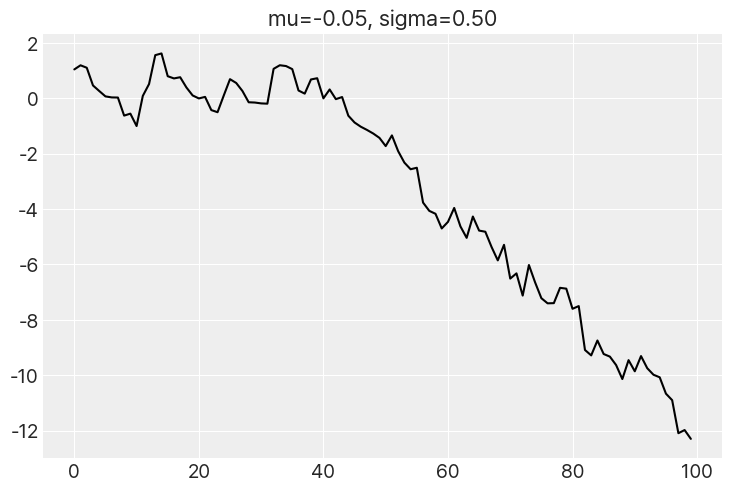

In [5]:
plt.title(f"mu={mu_true:.2f}, sigma={sigma_true:.2f}")
plt.plot(y_obs, color="k");

In [6]:
with pm.Model() as m:
    mu = pm.Normal("mu")
    sigma = pm.Normal("sigma")
    y = pm.GaussianRandomWalk(
        "y", 
        init_dist=pm.Normal.dist(), 
        mu=mu, 
        sigma=sigma,
        observed=y_obs
    )

    idata = pm.sample(random_seed=rng)

Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [mu, sigma]


Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 2 seconds.


In [7]:
with pm.Model() as forecast_m:
    mu = pm.Normal("mu")

    # Flat sigma for illustration purposes
    sigma = pm.Flat("sigma")

    # init_dist now starts on last observed value of y
    pm.GaussianRandomWalk(
        "y_forecast",
        init_dist=pm.DiracDelta.dist(y_obs[-1]),
        mu=mu,
        sigma=sigma,
        steps=99,
    )

    pp = pm.sample_posterior_predictive(
        idata, 
        var_names=["y_forecast"], 
        predictions=True, 
        random_seed=rng,
    )

Sampling: [y_forecast]


In [9]:
pp

Inference data with groups:
	> predictions

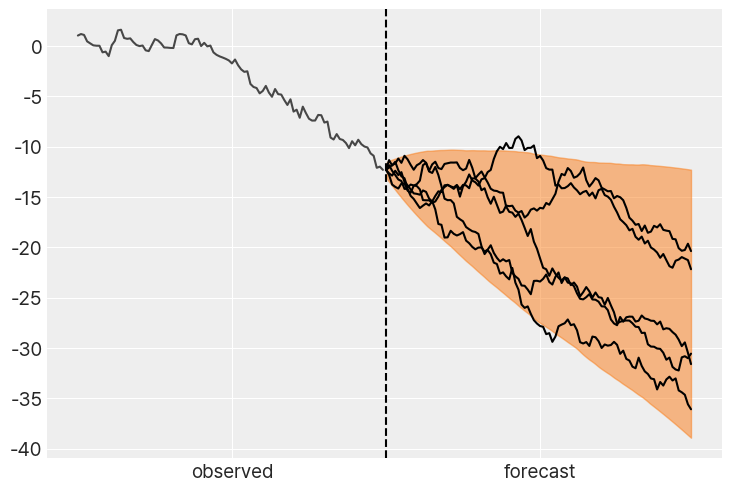

In [8]:
steps = np.arange(100, 200)
ax = az.plot_hdi(x=steps, y=pp.predictions["y_forecast"])
# Plot first five forecasts
for i in range(5):
    y = pp.predictions["y_forecast"].isel(chain=0, draw=i)
    ax.plot(steps, y, color="k")
ax.plot(np.arange(100), y_obs, color="k", alpha=0.7)
ax.axvline(100, ls="--", color="k")
ax.set_xticks([50, 150])
ax.set_xticklabels(["observed", "forecast"]);